# Feature Engineering and Regression Pipeline


In [1]:
# importing all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error



# Makes plots look nicer
sns.set_theme(style='whitegrid')

In [2]:
# Load the dataset
# load the CSV file into a pandas DataFrame.
# parse_dates tells pandas to automatically read 'transaction_date'
# as a proper date (datetime) object instead of a plain string.

df = pd.read_csv('q3_retail_promotions.csv', parse_dates=['transaction_date'])

print(f"Dataset shape: {df.shape}  →  {df.shape[0]} rows, {df.shape[1]} columns")
print("\nColumn names:", df.columns.tolist())
print("\nDate range:", df['transaction_date'].min(), "→", df['transaction_date'].max())
df.head(5)

Dataset shape: (1200, 9)  →  1200 rows, 9 columns

Column names: ['transaction_date', 'store_id', 'store_size', 'location_type', 'promotion_type', 'is_weekend', 'is_festival', 'competition_density', 'items_sold']

Date range: 2022-01-01 00:00:00 → 2024-12-31 00:00:00


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


---
## Date Feature Engineering

**Why?**  
The raw column `transaction_date` is just a date stamp the model can't learn from it directly.  
But *parts* of the date carry useful patterns:
- **Year** → captures long-term trends (sales may grow year over year)
- **Month** → captures seasonality (e.g. festive months sell more)
- **Day of week** → captures weekly patterns (weekends vs weekdays)
- **Is month end** → captures end-of-month buying spikes (payday effect)

By extracting these, we turn one useless column into four informative numeric features.

In [3]:
# Extract date features

# .dt accessor lets us extract parts of a datetime column
df['year']        = df['transaction_date'].dt.year         # e.g. 2022, 2023, 2024
df['month']       = df['transaction_date'].dt.month        # 1=Jan ... 12=Dec
df['day_of_week'] = df['transaction_date'].dt.dayofweek   # 0=Mon ... 6=Sun

# is_month_end: 1 if the day of month is >= 25, else 0
# This captures end-of-month buying surges (people spend near payday)
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("Date features created!")
print("Sample of new columns:")
df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(10)

Date features created!
Sample of new columns:


,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0
5,2022-01-03,2022,1,0,0
6,2022-01-04,2022,1,1,0
7,2022-01-04,2022,1,1,0
8,2022-01-05,2022,1,2,0
9,2022-01-05,2022,1,2,0


In [4]:
# Quick sanity check
print("year unique values      :", sorted(df['year'].unique()))
print("month range             :", df['month'].min(), "→", df['month'].max())
print("day_of_week range       :", df['day_of_week'].min(), "→", df['day_of_week'].max())
print("is_month_end value counts:\n", df['is_month_end'].value_counts())

year unique values      : [np.int32(2022), np.int32(2023), np.int32(2024)]
month range             : 1 → 12
day_of_week range       : 0 → 6
is_month_end value counts:
 is_month_end
0    959
1    241
Name: count, dtype: int64


---
## Temporal Train-Test Split

**Why sort by date instead of using random split?**  

Our data is **time-ordered** each row represents a transaction on a specific date.  
If we use a random split, training data might include *future* dates while the test set has *past* dates.  
This causes **data leakage** the model accidentally sees future information and appears to perform well, but will fail in real life.

**The correct approach:**  
- Sort by date → Train on the **first 80%** (older data) → Test on the **last 20%** (most recent data)  
- This mimics real-world forecasting: train on the past, predict the future.

In [5]:
# Temporal Train-Test Split

# Step 1: Sort data chronologically (oldest → newest)
df_sorted = df.sort_values('transaction_date').reset_index(drop=True)

# Step 2: Find the cutoff index (80% mark)
n = len(df_sorted)
cutoff = int(n * 0.80)   # 80% for training

print(f"Total records     : {n}")
print(f"Training records  : {cutoff}  (first 80%)")
print(f"Testing records   : {n - cutoff}  (last 20%)")

# Step 3: Slice into train and test
train_df = df_sorted.iloc[:cutoff]    # rows 0 to cutoff-1
test_df  = df_sorted.iloc[cutoff:]    # rows cutoff to end

print(f"\nTraining date range : {train_df['transaction_date'].min().date()}  →  {train_df['transaction_date'].max().date()}")
print(f"Testing date range  : {test_df['transaction_date'].min().date()}  →  {test_df['transaction_date'].max().date()}")

Total records     : 1200
Training records  : 960  (first 80%)
Testing records   : 240  (last 20%)

Training date range : 2022-01-01  →  2024-06-11
Testing date range  : 2024-06-12  →  2024-12-31


In [6]:
# Define Features (X) and Target (y)

# We drop 'transaction_date' and 'items_sold' from X.
# - transaction_date: replaced by the 4 date features we created
# - items_sold: this is our target (what we want to predict)

FEATURES = [
    'store_id', 'store_size', 'location_type', 'promotion_type',
    'is_weekend', 'is_festival', 'competition_density',
    'year', 'month', 'day_of_week', 'is_month_end'
]
TARGET = 'items_sold'

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("\nFeature list:", FEATURES)

X_train shape: (960, 11)
X_test shape : (240, 11)

Feature list: ['store_id', 'store_size', 'location_type', 'promotion_type', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']


---
## Preprocessing Pipeline

**Why do we need preprocessing?**  
Our dataset has two kinds of columns:

| Type | Columns | Problem | Solution |
|------|---------|---------|----------|
| **Categorical** (text labels) | `promotion_type`, `location_type`, `store_size` | ML models can't process words like "bogo" or "urban" directly | **One-Hot Encoding** → convert to 0/1 columns |
| **Numerical** (numbers) | `store_id`, `competition_density`, etc. | Features have very different scales (e.g. store_id goes 1-50, competition_density goes 1-9) | **StandardScaler** → re-scale all numbers to mean=0, std=1 |

**`ColumnTransformer`** lets us apply *different* transformations to *different* columns all in one clean object.  
**`Pipeline`** chains the transformer + model together, so fitting and predicting stay simple and leak-proof.


In [7]:
# Build the Preprocessing Pipeline

# Define which columns need which treatment 

# Categorical: text columns → One-Hot Encoding
# handle_unknown='ignore' means if test set has a new category label,
# we don't crash — we just ignore it.
categorical_cols = ['promotion_type', 'location_type', 'store_size']

# Numerical: all remaining feature columns → StandardScaler
numerical_cols = ['store_id', 'is_weekend', 'is_festival',
                  'competition_density', 'year', 'month',
                  'day_of_week', 'is_month_end']

# ColumnTransformer applies each transformer to the right columns
# 'passthrough' would keep columns unchanged — but here we process everything
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(),                       numerical_cols)
])

print("ColumnTransformer defined!")
print(f"   → OneHotEncoder  on : {categorical_cols}")
print(f"   → StandardScaler on : {numerical_cols}")

ColumnTransformer defined!
   → OneHotEncoder  on : ['promotion_type', 'location_type', 'store_size']
   → StandardScaler on : ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']


---
## Model Training and Evaluation

We train two models:

| Model | How it works | Strength |
|-------|-------------|----------|
| **Linear Regression** | Fits a straight-line equation to the data | Simple, fast, interpretable |
| **Random Forest** | Builds many decision trees and averages their predictions | Handles non-linear patterns, usually more accurate |

We evaluate with:
- **RMSE** (Root Mean Squared Error) penalizes large errors more
- **MAE** (Mean Absolute Error) average size of errors in original units (items)


In [8]:
# Build and Train Both Pipelines

# Pipeline 1: Linear Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),        # Step 1: transform the data
    ('model', LinearRegression())           # Step 2: fit a linear model
])

# Pipeline 2: Random Forest 
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),        # Step 1: same transformer
    ('model', RandomForestRegressor(
        n_estimators=100,                  # build 100 trees
        random_state=42                    # for reproducibility
    ))
])

# FIT only on training data 
# IMPORTANT: We never call .fit() on test data!
# The scaler and encoder learn statistics (mean, std, categories)
# only from training data — then apply those same stats to test data.

print("Training Linear Regression...")
lr_pipeline.fit(X_train, y_train)
print("Linear Regression trained!")

print("\nTraining Random Forest (may take a few seconds)...")
rf_pipeline.fit(X_train, y_train)
print("Random Forest trained!")

Training Linear Regression...
Linear Regression trained!

Training Random Forest (may take a few seconds)...
Random Forest trained!


In [9]:
# Evaluate Both Models on Test Set

# Generate predictions on the test set
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

# Calculate metrics
# RMSE = sqrt(mean of (actual - predicted)^2)
# MAE  = mean of |actual - predicted|

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae  = mean_absolute_error(y_test, y_pred_lr)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae  = mean_absolute_error(y_test, y_pred_rf)

# Pretty print results
print("="*45)
print(f"{'Model':<25} {'RMSE':>8} {'MAE':>8}")
print("="*45)
print(f"{'Linear Regression':<25} {lr_rmse:>8.2f} {lr_mae:>8.2f}")
print(f"{'Random Forest':<25} {rf_rmse:>8.2f} {rf_mae:>8.2f}")
print("="*45)
print("\nLower RMSE/MAE = better predictions")
print(f" Random Forest improvement in RMSE: {((lr_rmse - rf_rmse)/lr_rmse*100):.1f}%")

Model                         RMSE      MAE
Linear Regression            27.12    21.05
Random Forest                30.84    24.24

Lower RMSE/MAE = better predictions
 Random Forest improvement in RMSE: -13.7%


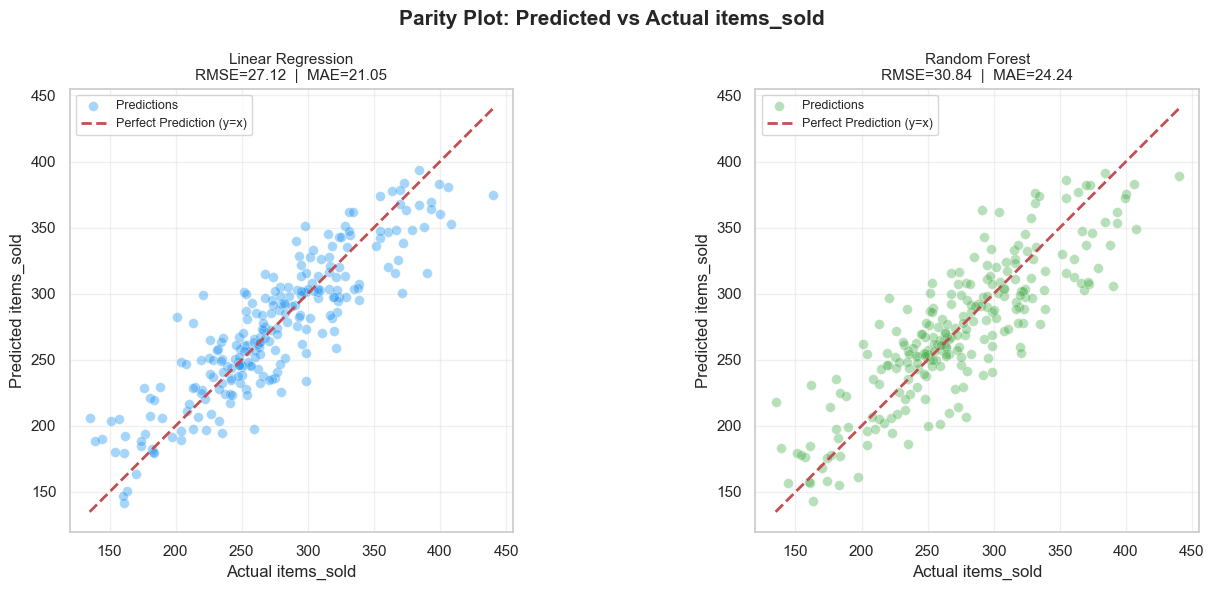


The red dashed diagonal = perfect model.
Dots closer to the line = fewer errors.


In [10]:
# Parity Plots (Predicted vs Actual)

# A parity plot shows predicted values on X-axis vs actual values on Y-axis.
# If a model is PERFECT, all dots fall on the diagonal line (y = x).
# Scattered dots = larger errors. We want dots as close to the line as possible.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Parity Plot: Predicted vs Actual items_sold', fontsize=15, fontweight='bold')

models_info = [
    ('Linear Regression', y_pred_lr, axes[0], '#2196F3'),
    ('Random Forest',     y_pred_rf, axes[1], '#4CAF50'),
]

for title, y_pred, ax, color in models_info:
    ax.scatter(y_test, y_pred, alpha=0.4, color=color, edgecolors='white',
               linewidth=0.5, s=50, label='Predictions')
    
    # Draw the diagonal reference line (perfect predictions)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'r--', linewidth=2, label='Perfect Prediction (y=x)')
    
    ax.set_xlabel('Actual items_sold', fontsize=12)
    ax.set_ylabel('Predicted items_sold', fontsize=12)
    ax.set_title(f'{title}\nRMSE={np.sqrt(mean_squared_error(y_test,y_pred)):.2f}  |  MAE={mean_absolute_error(y_test,y_pred):.2f}',
                 fontsize=11)
    ax.legend(fontsize=9)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\nThe red dashed diagonal = perfect model.")
print("Dots closer to the line = fewer errors.")

In [11]:
# Feature Importances from Random Forest

# Random Forest tells us how much each feature contributed
# to reducing prediction error across all trees.
# Higher importance = more influential in predicting items_sold.

# Get the fitted RandomForestRegressor from the pipeline
rf_model = rf_pipeline.named_steps['model']

# Get the fitted preprocessor to retrieve feature names after encoding
fitted_preprocessor = rf_pipeline.named_steps['preprocessor']

# One-Hot Encoding creates new column names — let's get all of them
ohe_feature_names = fitted_preprocessor \
    .named_transformers_['cat'] \
    .get_feature_names_out(categorical_cols).tolist()

all_feature_names = ohe_feature_names + numerical_cols

# Get importances and pair with names
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("All Feature Importances (sorted):")
print(feat_imp_df.to_string(index=False))

All Feature Importances (sorted):
                      Feature  Importance
                  is_festival    0.173473
             store_size_small    0.167683
          location_type_urban    0.108378
                  day_of_week    0.086316
                   is_weekend    0.061208
                     store_id    0.054882
          location_type_rural    0.053794
             store_size_large    0.051113
          competition_density    0.050805
                        month    0.037383
          promotion_type_bogo    0.030311
            store_size_medium    0.027020
promotion_type_loyalty_points    0.023142
     location_type_semi-urban    0.017195
                         year    0.017154
 promotion_type_flat_discount    0.015956
promotion_type_category_offer    0.010776
     promotion_type_free_gift    0.008061
                 is_month_end    0.005350



TOP 5 Most Influential Features:
1. is_festival                     0.1735  ██████████████████████████████████
2. store_size_small                0.1677  █████████████████████████████████
3. location_type_urban             0.1084  █████████████████████
4. day_of_week                     0.0863  █████████████████
5. is_weekend                      0.0612  ████████████


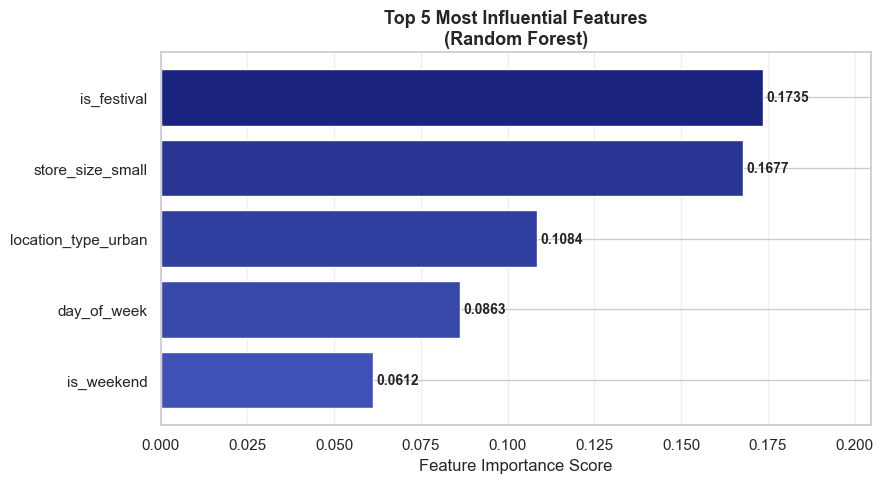

In [12]:
# Top 5 Most Influential Features

top5 = feat_imp_df.head(5)

print("\nTOP 5 Most Influential Features:")
print("="*40)
for i, row in top5.iterrows():
    bar = '█' * int(row['Importance'] * 200)
    print(f"{i+1}. {row['Feature']:<30}  {row['Importance']:.4f}  {bar}")
print("="*40)

# --- Bar chart of top 5 ---
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#1a237e','#283593','#303f9f','#3949ab','#3f51b5']
bars = ax.barh(top5['Feature'][::-1], top5['Importance'][::-1],
               color=colors[::-1], edgecolor='white')

# Add value labels on bars
for bar, val in zip(bars, top5['Importance'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Top 5 Most Influential Features\n(Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlim(0, top5['Importance'].max() * 1.18)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()